In [1]:
!pip install openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re
import unicodedata

In [2]:
# 2. LECTURA DEL ARCHIVO
# ============================================================
df = pd.read_excel('/content/comparación texto.xlsx')
print(" Archivo cargado correctamente")
print(f"   Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print(df.head())

 Archivo cargado correctamente
   Filas: 6 | Columnas: 2
                      Nombre  \
0  Las ruinas circulares JLB   
1   Las ruinas circulares IA   
2    La casa de asterion JLB   
3     La casa de asterion IA   
4                   El golem   

                                               Texto  
0  \nNadie lo vio desembarcar en la unánime noche...  
1  En algún lugar que la memoria no ha logrado fi...  
2  El hecho es que soy único. No me interesa lo q...  
3  Sé que me acusan de soberbia. También de trist...  
4  Si (como afirma el griego en el Cratilo)\nel n...  


In [6]:
# 3. PREPROCESAMIENTO DE TEXTO (español)

STOPWORDS_ES = set([
    'de','la','el','en','y','a','los','del','se','las','por','un',
    'con','una','su','para','es','al','lo','como','más','pero','sus',
    'le','ya','o','fue','este','ha','si','sobre','entre','cuando',
    'también','me','hay','muy','sin','ser','nos','esto','que','no',
    'te','mi','uno','bien','donde','desde','todo','esta','son','están'
])

def limpiar_texto(texto):
    # Minúsculas
    texto = str(texto).lower()
    # Eliminar acentos
    texto = unicodedata.normalize('NFD', texto)
    texto = ''.join(c for c in texto if unicodedata.category(c) != 'Mn')
    # Eliminar puntuación y números
    texto = re.sub(r'[^a-z\s]', '', texto)
    # Eliminar stopwords
    palabras = [p for p in texto.split() if p not in STOPWORDS_ES]
    return ' '.join(palabras)

df['Texto_limpio'] = df['Texto'].apply(limpiar_texto)
nombres = df['Nombre'].tolist()

print("\n Preprocesamiento completado")
print(df[['Nombre', 'Texto_limpio']].to_string())


 Preprocesamiento completado
                      Nombre                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [7]:
# 4. ONE-HOT ENCODING (vocabulario compartido)

vocabulario = sorted(set(
    palabra
    for texto in df['Texto_limpio']
    for palabra in texto.split()
))

# Crear matriz One-Hot (presencia/ausencia de cada palabra)
def one_hot_texto(texto, vocab):
    palabras = set(texto.split())
    return [1 if palabra in palabras else 0 for palabra in vocab]

ohe_matrix = np.array([one_hot_texto(t, vocabulario) for t in df['Texto_limpio']])

print(f"\n One-Hot Encoding: matriz {ohe_matrix.shape}")


 One-Hot Encoding: matriz (6, 668)


In [8]:
ohe_matrix

array([[1, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 1, 0],
       [0, 0, 1, ..., 0, 0, 0]])

In [9]:
# 5. TF-IDF
# ============================================================
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Texto_limpio']).toarray()

print(f" TF-IDF: matriz {tfidf_matrix.shape}")


 TF-IDF: matriz (6, 668)


In [10]:
tfidf_matrix

array([[0.07589389, 0.        , 0.        , ..., 0.        , 0.        ,
        0.07589389],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.08755475, 0.        , ..., 0.21538845, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.04659853, 0.05682648,
        0.        ],
       [0.        , 0.        , 0.07881058, ..., 0.        , 0.        ,
        0.        ]])

In [11]:
# 6. SIMILITUD COSENO (para mapas de calor entre documentos)

sim_ohe   = cosine_similarity(ohe_matrix)
sim_tfidf = cosine_similarity(tfidf_matrix)


In [12]:
sim_ohe

array([[1.        , 0.15478181, 0.0769117 , 0.04347004, 0.06201934,
        0.09094468],
       [0.15478181, 1.        , 0.0291661 , 0.05494837, 0.09977626,
        0.15033068],
       [0.0769117 , 0.0291661 , 1.        , 0.13761249, 0.07649366,
        0.04745642],
       [0.04347004, 0.05494837, 0.13761249, 1.        , 0.08646754,
        0.10728836],
       [0.06201934, 0.09977626, 0.07649366, 0.08646754, 1.        ,
        0.1449525 ],
       [0.09094468, 0.15033068, 0.04745642, 0.10728836, 0.1449525 ,
        1.        ]])

In [13]:
sim_tfidf

array([[1.        , 0.12201444, 0.04765591, 0.01752098, 0.0497833 ,
        0.06175591],
       [0.12201444, 1.        , 0.01378371, 0.05134234, 0.07608037,
        0.12259444],
       [0.04765591, 0.01378371, 1.        , 0.15897439, 0.05282649,
        0.02305389],
       [0.01752098, 0.05134234, 0.15897439, 1.        , 0.06060185,
        0.06355254],
       [0.0497833 , 0.07608037, 0.05282649, 0.06060185, 1.        ,
        0.18003385],
       [0.06175591, 0.12259444, 0.02305389, 0.06355254, 0.18003385,
        1.        ]])

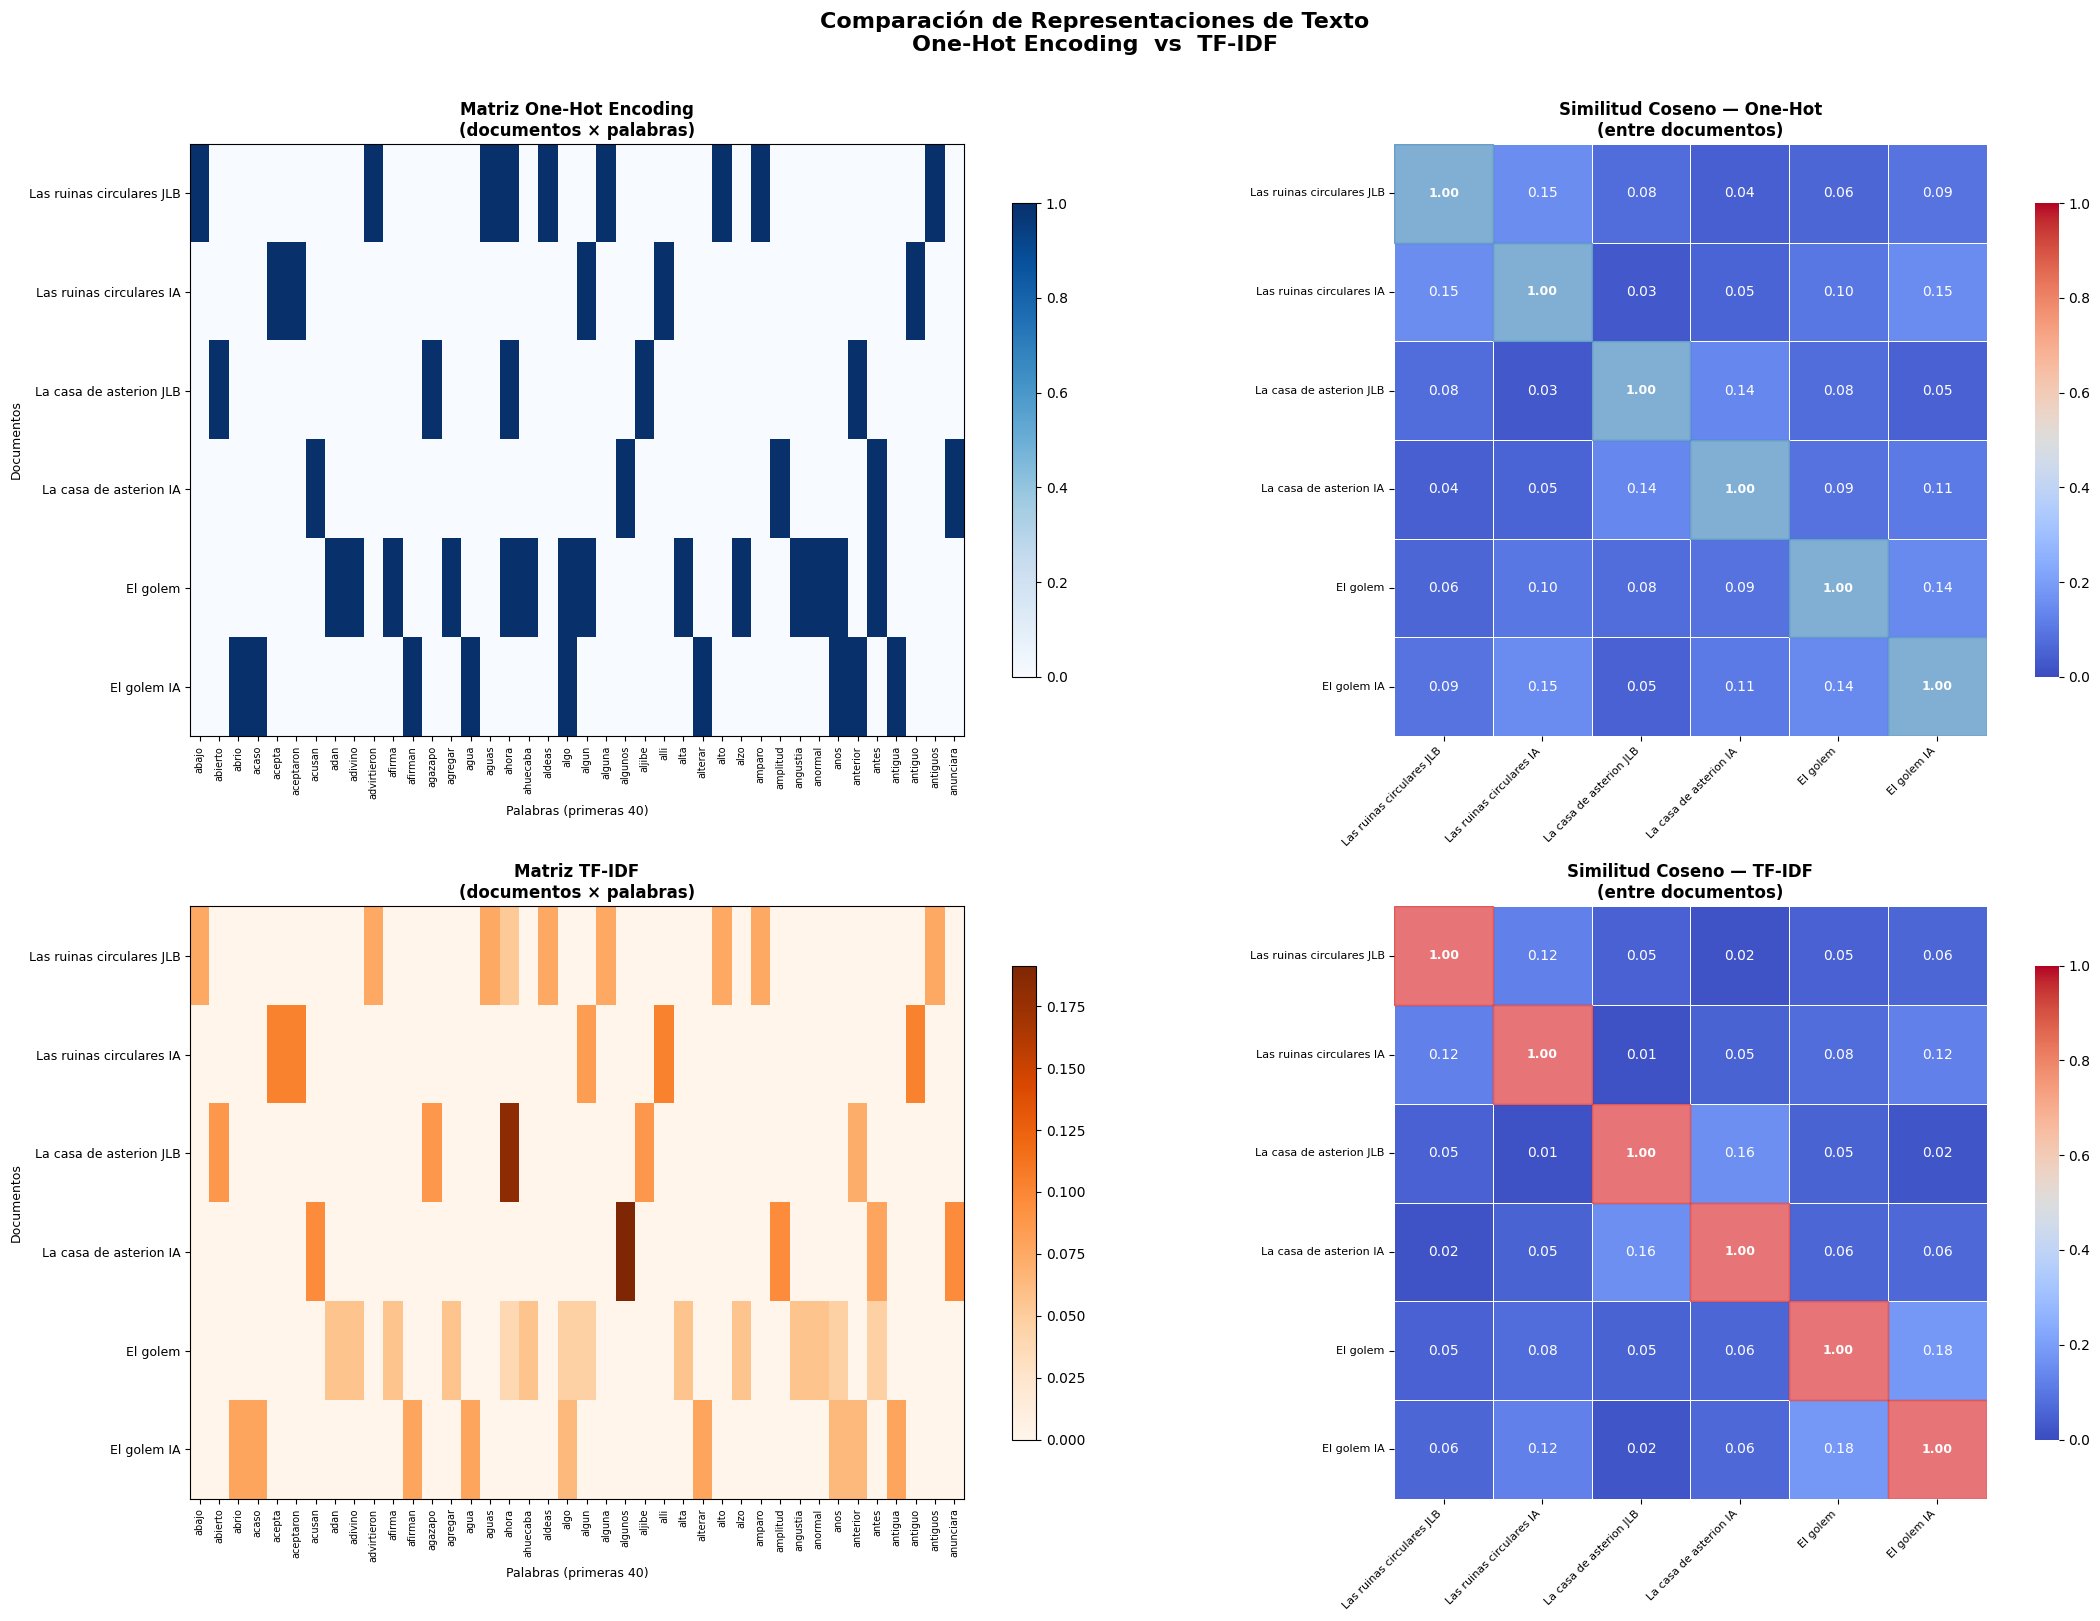


 Gráficas generadas y guardadas como 'comparacion_texto.png'


In [15]:
# 7. VISUALIZACIONES
# ============================================================
etiquetas = nombres   # nombres de los documentos

fig, axes = plt.subplots(2, 2, figsize=(22, 16))
fig.suptitle('Comparación de Representaciones de Texto\nOne-Hot Encoding  vs  TF-IDF',
             fontsize=16, fontweight='bold', y=1.01)

# ---------- Paletas ----------
pal_ohe   = 'Blues'
pal_tfidf = 'Oranges'
pal_sim   = 'coolwarm'

# ──────────────────────────────────────────────
# 7a. Matriz One-Hot (documentos × palabras)
# ──────────────────────────────────────────────
ax = axes[0, 0]
# Mostrar solo las primeras 40 palabras para legibilidad
max_palabras = min(40, len(vocabulario))
im = ax.imshow(ohe_matrix[:, :max_palabras], aspect='auto', cmap=pal_ohe, interpolation='nearest')
ax.set_title('Matriz One-Hot Encoding\n(documentos × palabras)', fontsize=12, fontweight='bold')
ax.set_yticks(range(len(etiquetas)))
ax.set_yticklabels(etiquetas, fontsize=9)
ax.set_xticks(range(max_palabras))
ax.set_xticklabels(vocabulario[:max_palabras], rotation=90, fontsize=7)
ax.set_xlabel('Palabras (primeras 40)', fontsize=9)
ax.set_ylabel('Documentos', fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.8)

# ──────────────────────────────────────────────
# 7b. Mapa de Calor One-Hot (similitud coseno)
# ──────────────────────────────────────────────
ax = axes[0, 1]
mask = np.eye(len(etiquetas), dtype=bool)   # resaltar diagonal
sns.heatmap(sim_ohe, ax=ax, cmap=pal_sim,
            xticklabels=etiquetas, yticklabels=etiquetas,
            annot=True, fmt='.2f', linewidths=0.5,
            vmin=0, vmax=1, square=True,
            mask=mask, cbar_kws={'shrink': 0.8})
# Diagonal con color distinto
for i in range(len(etiquetas)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color='#2c7bb6', alpha=0.6))
    ax.text(i + 0.5, i + 0.5, '1.00', ha='center', va='center',
            fontsize=9, color='white', fontweight='bold')
ax.set_title('Similitud Coseno — One-Hot\n(entre documentos)', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

# ──────────────────────────────────────────────
# 7c. Matriz TF-IDF (documentos × palabras)
# ──────────────────────────────────────────────
ax = axes[1, 0]
max_palabras_tfidf = min(40, tfidf_matrix.shape[1])
vocab_tfidf = tfidf_vectorizer.get_feature_names_out()
im2 = ax.imshow(tfidf_matrix[:, :max_palabras_tfidf], aspect='auto',
                cmap=pal_tfidf, interpolation='nearest')
ax.set_title('Matriz TF-IDF\n(documentos × palabras)', fontsize=12, fontweight='bold')
ax.set_yticks(range(len(etiquetas)))
ax.set_yticklabels(etiquetas, fontsize=9)
ax.set_xticks(range(max_palabras_tfidf))
ax.set_xticklabels(vocab_tfidf[:max_palabras_tfidf], rotation=90, fontsize=7)
ax.set_xlabel('Palabras (primeras 40)', fontsize=9)
ax.set_ylabel('Documentos', fontsize=9)
plt.colorbar(im2, ax=ax, shrink=0.8)

# ──────────────────────────────────────────────
# 7d. Mapa de Calor TF-IDF (similitud coseno)
# ──────────────────────────────────────────────
ax = axes[1, 1]
sns.heatmap(sim_tfidf, ax=ax, cmap=pal_sim,
            xticklabels=etiquetas, yticklabels=etiquetas,
            annot=True, fmt='.2f', linewidths=0.5,
            vmin=0, vmax=1, square=True,
            mask=mask, cbar_kws={'shrink': 0.8})
for i in range(len(etiquetas)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color='#d7191c', alpha=0.6))
    ax.text(i + 0.5, i + 0.5, '1.00', ha='center', va='center',
            fontsize=9, color='white', fontweight='bold')
ax.set_title('Similitud Coseno — TF-IDF\n(entre documentos)', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('comparacion_texto.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Gráficas generadas y guardadas como 'comparacion_texto.png'")
